In [1]:
#!/usr/bin/env python3
"""
Multi-compartmental TCR cell M_type example

File: TCRm.py

Copyright 2025 NeuroML contributors
Authors: Hua Cheng
"""

from pyneuroml.analysis import generate_current_vs_frequency_curve
from neuroml import NeuroMLDocument
from neuroml.utils import component_factory
from pyneuroml import pynml
from pyneuroml.lems import LEMSSimulation
from pyneuroml.plot.PlotMorphology import plot_2D
import numpy as np
import math
from neuroml import Cell, NeuroMLDocument
from neuroml.utils import component_factory

INFO:numexpr.utils:NumExpr defaulting to 16 threads.


In [2]:
def create_TCRm_cell():
    nml_cell_doc = NeuroMLDocument(id="TCRm_cell")
    cell = nml_cell_doc.add(Cell,id="TCRm", neuro_lex_id="NLXCELL:091206")  # type neuroml.Cell
    cell.summary()
    cell.info(show_contents=True)
    cell.morphology.info(show_contents=True)

    cell.add_unbranched_segment_group("soma_0")
    diam_soma = 20.0
    diam_axon = 1.6
    diam_dendrite = 1.46
    
    soma_0 = cell.add_segment(
        prox=[0.0, 0.0, 0.0, diam_soma],
        dist=[0.0, 21.0, 0.0, diam_soma],
        name="Seg0_soma_0",
        group_id="soma_0",
        seg_type="soma"
    )

    soma_1 = cell.add_segment(
        prox=None,
        dist=[-9.179392E-7, 42.0, 0.0, diam_soma],
        name="Seg1_soma_0",
        parent=soma_0,
        group_id="soma_0",
        seg_type="soma"
    )

    # Add axon segments
    cell.add_unbranched_segments(
        [
            [0.0, 21.0, 0.0, diam_axon],
            [9.179392E-7, 0.0, 0.0, diam_axon],
            [-1.7484616E-7, -25.0, 0.0, diam_axon],
        ],
        parent=soma_0,
        fraction_along=0.0,
        group_id="axon_0",
        seg_type="axon"
    )

    cell.add_unbranched_segments(
        [
            [-1.7484616E-7, -25.0, 0.0, diam_axon-0.5],
            [-1.2676315E-6, -50.0, 0.0, diam_axon-0.5],
            [-3.9497368E-6, -75.0, 0.0, diam_axon-0.5],
        ],
        parent=soma_1,
        fraction_along=0.0,
        group_id="axon_1",
        seg_type="axon"
    )

    cell.add_unbranched_segments(
        [
            [-3.9497368E-6, -75.0, 0.0, diam_axon-0.6],
            [-6.6318216E-6, -100.0, 0.0, diam_axon-0.6],
            [9.735456, -123.02701, 0.0, diam_axon-0.6],
        ],
        parent=soma_1,
        fraction_along=0.0,
        group_id="axon_2",
        seg_type="axon"
    )

    cell.add_unbranched_segments(
        [
            [9.735456, -123.02701, 0.0, diam_axon-0.7],
            [19.470907, -146.053, 0.0, diam_axon-0.7],
            [29.206408, -169.08, 0.0, diam_axon-0.7],
        ],
        parent=soma_1,
        fraction_along=0.0,
        group_id="axon_3",
        seg_type="axon"
    )

    cell.add_unbranched_segments(
        [
            [29.206408, -169.08, 0.0, diam_axon-0.8],
            [-6.6318216E-6, -100.0, 0.0, diam_axon-0.8],
            [-9.735474, -123.02701, 0.0, diam_axon-0.8],
        ],
        parent=soma_1,
        fraction_along=0.0,
        group_id="axon_4",
        seg_type="axon"
    )

    cell.add_unbranched_segments(
        [
            [-9.735474, -123.02701, 0.0, diam_axon-0.9],
            [-19.470892, -146.053, 0.0, diam_axon-0.9],
            [-29.206392, -169.08, 0.0, diam_axon-0.9],
        ],
        parent=soma_1,
        fraction_along=0.0,
        group_id="axon_5",
        seg_type="axon"
    )
    
    num_dendrites = 160
    radius1 = 50
    radius2 = 250
    y_base = 42.0
    diam_dendrite = 1.46

    # Store dendrite groups for referencing parent segments
    dendrite_groups = {}
    
    layer1_count = 10
    for i in range(layer1_count):
        angle = 2 * math.pi * i / layer1_count
        x1 = radius1 * math.cos(angle)
        z1 = radius1 * math.sin(angle)
        x2 = radius2 * math.cos(angle)
        z2 = radius2 * math.sin(angle)
        
        dend_coords = [
            [0.0, y_base, 0.0, diam_dendrite],
            [x1, 0.5 * y_base + 0.5 * radius1, z1, diam_dendrite],
            [x2, y_base + radius1, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=soma_1,
            fraction_along=1.0,
            group_id=f"primary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"primary_dend_{i}"] = group

    layer2_count = 30
    for i in range(layer2_count):
        # Attach to primary dendrites in a distributed manner
        parent_idx = i * layer1_count // layer2_count
        parent_group = dendrite_groups[f"primary_dend_{parent_idx}"]
        last_segment_id = parent_group.members[-1].segments
        last_segment = cell.get_segment(last_segment_id)
        
        # Get the distal point of the parent segment as the new origin
        parent_x = last_segment.distal.x
        parent_y = last_segment.distal.y
        parent_z = last_segment.distal.z
        
        angle = 2 * math.pi * i / layer2_count + math.pi/60  # Small twist
        twist_angle = (i * 0.02) % (2 * math.pi)  # Minimal twist
       # Make secondary dendrites shorter than primary ones
        x1 = parent_x + radius1 * math.cos(angle) * 0.7
        z1 = parent_z + radius1 * math.sin(angle) * 0.7
        x2 = parent_x + radius2 * math.cos(angle + twist_angle) * 0.7
        z2 = parent_z + radius2 * math.sin(angle + twist_angle) * 0.7

        dend_coords = [
            [parent_x, parent_y, parent_z, diam_dendrite],
            [x1, parent_y + 0.4 * radius1 * 0.7, z1, diam_dendrite],
            [x2, parent_y + 0.8 * radius1 * 0.7, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=last_segment,
            fraction_along=1.0,
            group_id=f"secondary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"secondary_dend_{i}"] = group

    layer3_count = 90
    for i in range(layer3_count):
        # Attach to secondary dendrites in a distributed manner
        parent_idx = i * layer2_count // layer3_count
        parent_group = dendrite_groups[f"secondary_dend_{parent_idx}"]
        last_segment_id = parent_group.members[-1].segments
        last_segment = cell.get_segment(last_segment_id)
        
        # Get the distal point of the parent segment as the new origin
        parent_x = last_segment.distal.x
        parent_y = last_segment.distal.y
        parent_z = last_segment.distal.z
        
        # Add a subtle twist to the child dendrites
        angle = 2 * math.pi * i / layer3_count + math.pi/90  # Very small base twist
        twist_angle = (i * 0.01) % (2 * math.pi)  # Minimal twist
        # Make tertiary dendrites shorter than secondary ones
        x1 = parent_x + radius1 * math.cos(angle) * 0.5
        z1 = parent_z + radius1 * math.sin(angle) * 0.5
        x2 = parent_x + radius2 * math.cos(angle + twist_angle) * 0.5
        z2 = parent_z + radius2 * math.sin(angle + twist_angle) * 0.5

        dend_coords = [
            [parent_x, parent_y, parent_z, diam_dendrite],
            [x1, parent_y + 0.3 * radius1 * 0.5, z1, diam_dendrite],
            [x2, parent_y + 0.6 * radius1 * 0.5, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=last_segment,
            fraction_along=1.0,
            group_id=f"tertiary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"tertiary_dend_{i}"] = group
    
    layer4_count = 30
    for i in range(layer4_count):
        # Attach to tertiary dendrites in a distributed manner
        parent_idx = i * layer3_count // layer4_count
        parent_group = dendrite_groups[f"tertiary_dend_{parent_idx}"]
        last_segment_id = parent_group.members[-1].segments
        last_segment = cell.get_segment(last_segment_id)
        
        # Get the distal point of the parent segment as the new origin
        parent_x = last_segment.distal.x
        parent_y = last_segment.distal.y
        parent_z = last_segment.distal.z
        
        # Add a subtle twist to the child dendrites
        angle = 2 * math.pi * i / layer4_count + math.pi/120  # Minimal base twist
        twist_angle = (i * 0.005) % (2 * math.pi)  # Very small twist
        # Make quaternary dendrites the shortest
        x1 = parent_x + radius1 * math.cos(angle) * 0.3
        z1 = parent_z + radius1 * math.sin(angle) * 0.3
        x2 = parent_x + radius2 * math.cos(angle + twist_angle) * 0.3
        z2 = parent_z + radius2 * math.sin(angle + twist_angle) * 0.3

        dend_coords = [
            [parent_x, parent_y, parent_z, diam_dendrite],
            [x1, parent_y + 0.2 * radius1 * 0.3, z1, diam_dendrite],
            [x2, parent_y + 0.4 * radius1 * 0.3, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=last_segment,
            fraction_along=1.0,
            group_id=f"quaternary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"quaternary_dend_{i}"] = group

    # Verify total count
    total_created = layer1_count + layer2_count + layer3_count + layer4_count
    print(f"Created dendritic tree with {total_created} dendrites (target: {num_dendrites})")

    # color groups for morphology plots
    den_seg_group = cell.get_segment_group("dendrite_group")
    den_seg_group.add("Property", tag="color", value="0.8 0 0")

    ax_seg_group = cell.get_segment_group("axon_group")
    ax_seg_group.add("Property", tag="color", value="0 0.8 0")

    soma_seg_group = cell.get_segment_group("soma_group")
    soma_seg_group.add("Property", tag="color", value="0 0 0.8")

    # Other cell properties
    cell.set_init_memb_potential("-70mV")
    cell.set_resistivity("0.15 kohm_cm")
    cell.set_specific_capacitance("1.3 uF_per_cm2")
    cell.set_spike_thresh("0.0 mV")

    # channels
    # ar_axon_group
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ar_axon",
                             cond_density="0.25 mS_per_cm2",
                             ion_channel="ar__m00_25",
                             ion_chan_def_file="ar__m00_25.channel.nml",
                             erev="-35.0 mV",
                             ion="ar",
                             group_id="axon_group")
    # ar_soma_group
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ar_soma",
                             cond_density="0.3 mS_per_cm2",
                             ion_channel="ar__m00_25",
                             ion_chan_def_file="ar__m00_25.channel.nml",
                             erev="-35.0 mV",
                             ion="ar",
                             group_id="soma_group")
    # ar_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ar_dendrite",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="ar__m00_25",
                             ion_chan_def_file="ar__m00_25.channel.nml",
                             erev="-35.0 mV",
                             ion="ar",
                             group_id="dendrite_group")

    # cal_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cal_soma",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="cal",
                             ion_chan_def_file="cal.channel.nml",
                             erev="125.0 mV",
                             ion="ca",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cal_dendrite",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="cal",
                             ion_chan_def_file="cal.channel.nml",
                             erev="125.0 mV",
                             ion="ca",
                             group_id="dendrite_group")
    # cat_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cat_soma",
                             cond_density="3.0 mS_per_cm2",
                             ion_channel="cat",
                             ion_chan_def_file="cat.channel.nml",
                             erev="125.0 mV",
                             ion="cat",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cat_dendrite",
                             cond_density="3.0 mS_per_cm2",
                             ion_channel="cat",
                             ion_chan_def_file="cat.channel.nml",
                             erev="125.0 mV",
                             ion="cat",
                             group_id="dendrite_group")
    # k2_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="k2_soma",
                             cond_density="2.0 mS_per_cm2",
                             ion_channel="k2",
                             ion_chan_def_file="k2.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="k2_dendrite",
                             cond_density="2.0 mS_per_cm2",
                             ion_channel="k2",
                             ion_chan_def_file="k2.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="dendrite_group")
    # ka_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ka_soma",
                             cond_density="6.0 mS_per_cm2",
                             ion_channel="ka",
                             ion_chan_def_file="ka.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ka_dendrite",
                             cond_density="6.0 mS_per_cm2",
                             ion_channel="ka",
                             ion_chan_def_file="ka.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="dendrite_group")
    # kahp_slower_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kahp_slower_soma",
                             cond_density="0.05 mS_per_cm2",
                            ion_channel="kahp_slower",
                            ion_chan_def_file="kahp_slower.channel.nml",
                            erev="-95.0 mV",
                            ion="k",
                            group_id="soma_group")  
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kahp_slower_dendrite",
                             cond_density="0.05 mS_per_cm2",
                            ion_channel="kahp_slower",
                            ion_chan_def_file="kahp_slower.channel.nml",
                            erev="-95.0 mV",
                            ion="k",
                            group_id="dendrite_group")
    # kc_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kc_soma_group",
                             cond_density="12.0 mS_per_cm2",
                             ion_channel="kc",
                             ion_chan_def_file="kc.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kc_dendrite_group",
                             cond_density="12.0 mS_per_cm2",
                             ion_channel="kc",
                             ion_chan_def_file="kc.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="dendrite_group")

    # kdr_soma
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kdr_soma",
                             cond_density="180.0 mS_per_cm2",
                             ion_channel="kdr",
                             ion_chan_def_file="kdr.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="soma_group")
    # kdr_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kdr_dendrite",
                             cond_density="22.5 mS_per_cm2",
                             ion_channel="kdr",
                             ion_chan_def_file="kdr.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="dendrite_group")
    # kdr_axon
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kdr_axon",
                             cond_density="33.75 mS_per_cm2",
                             ion_channel="kdr",
                             ion_chan_def_file="kdr.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="axon_group")

    # km_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="km_soma",
                            cond_density="0.5 mS_per_cm2",   
                            ion_channel="km",
                            ion_chan_def_file="km.channel.nml",
                            erev="-95.0 mV",
                            ion="k",
                            group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="km_dendrite",
                            cond_density="0.5 mS_per_cm2",   
                            ion_channel="km",
                            ion_chan_def_file="km.channel.nml",
                            erev="-95.0 mV",
                            ion="k",
                            group_id="dendrite_group")
    # naf_tcr_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="naf_tcr_soma",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="naf_tcr__sh_hmin7__sh_m_imin3__sh_m_rmin2_5",
                             ion_chan_def_file="naf_tcr__sh_hmin7__sh_m_imin3__sh_m_rmin2_5.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="naf_tcr_dendrite",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="naf_tcr__sh_hmin7__sh_m_imin3__sh_m_rmin2_5",
                             ion_chan_def_file="naf_tcr__sh_hmin7__sh_m_imin3__sh_m_rmin2_5.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="dendrite_group")

    # napf_tcr_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="napf_tcr_soma",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="napf_tcr__a0__b0__c0__d0__fastNa_shift7",
                             ion_chan_def_file="napf_tcr__a0__b0__c0__d0__fastNa_shift7.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="soma_group") 
    cell.add_channel_density(nml_cell_doc,
                             cd_id="napf_tcr_dendrite",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="napf_tcr__a0__b0__c0__d0__fastNa_shift7",
                             ion_chan_def_file="napf_tcr__a0__b0__c0__d0__fastNa_shift7.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="dendrite_group")

    # kc_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kc_soma",
                             cond_density="20.0 mS_per_cm2",
                             ion_channel="kc",
                             ion_chan_def_file="kc.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="soma_group") 
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kc_dendrite",
                             cond_density="20.0 mS_per_cm2",
                             ion_channel="kc",
                             ion_chan_def_file="kc.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="dendrite_group")  

    # kdr_axon
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kdr_axon",
                             cond_density="33.75 mS_per_cm2",
                             ion_channel="kdr",
                             ion_chan_def_file="kdr.channel.nml",
                             erev="-195.0 mV",
                             ion="k",
                             group_id="axon_group")


    # napf_tcr_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="napf_tcr_soma",
                             cond_density="0.01 mS_per_cm2",
                             ion_channel="napf_tcr__a0__b0__c0__d0__fastNa_shift7",
                             ion_chan_def_file="napf_tcr__a0__b0__c0__d0__fastNa_shift7.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="napf_tcr_dendrite",
                             cond_density="0.01 mS_per_cm2",
                             ion_channel="napf_tcr__a0__b0__c0__d0__fastNa_shift7",
                             ion_chan_def_file="napf_tcr__a0__b0__c0__d0__fastNa_shift7.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="dendrite_group")


    # pas_soma_prox_dends
    cell.add_channel_density(nml_cell_doc, 
                             cd_id="pas_soma",
                             cond_density="1.0 mS_per_cm2",
                             ion_channel="pas",
                             ion_chan_def_file="pas.channel.nml",
                             erev="-70.0 mV",
                             ion="non_specific",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc, 
                             cd_id="pas_dendrite",
                             cond_density="1.0 mS_per_cm2",
                             ion_channel="pas",
                             ion_chan_def_file="pas.channel.nml",
                             erev="-70.0 mV",
                             ion="non_specific",
                             group_id="dendrite_group")
    
    
    cell.optimise_segment_groups()
    nml_cell_file = "TCRm.cell.nml"
    base_name = nml_cell_file.split('.')[0]
    pynml.write_neuroml2_file(nml_cell_doc, nml_cell_file)
    planes = ['yz', 'xz', 'xy','zx','zy','yx']
    for plane in planes:
        plot_2D(
            nml_cell_file, plane2d=plane, verbose=True ,nogui=True,save_to_file=f"{base_name}_{plane}.png",
            square=False,plot_type="detailed")

    nml_doc = pynml.read_neuroml2_file(nml_cell_file)
    generate_current_vs_frequency_curve(
        nml_cell_file,
        nml_doc.cells[0].id,
        start_amp_nA=0.2,
        end_amp_nA=1.0,
        step_nA=0.05,
        pre_zero_pulse=0,
        post_zero_pulse=0,
        dt=0.01,
        analysis_duration=30,
        spike_threshold_mV=0.0,
        plot_voltage_traces=True,
        plot_iv=True,
        save_if_figure_to=f"{base_name}_if.png",
        save_iv_figure_to=f"{base_name}_iv.png",
        simulator='jNeuroML_NEURON',
        title_above_plot=True)
    return nml_cell_file



In [3]:
def create_TCRm_network():
    net_doc = NeuroMLDocument(id="network",notes="TCRm net")
    net_doc_fn = "TCRm.net.nml"
    net_doc.add("IncludeType", href=create_TCRm_cell())

    net = net_doc.add("Network", id="TCRm_net", validate=False)
    # Create a population: convenient to create many cells of the same type
    pop = net.add("Population", id="pop0", notes="A population for our cell",
                  component="TCRm", size=1, type="populationList",
                  validate=False)
    pop.add("Instance", id=0, location=component_factory("Location", x=0., y=0., z=0.))
    
    # Input
    net_doc.add("PulseGenerator",id="pg_nRTil", notes="Simple pulse generator", delay="100ms", duration="100ms", amplitude="0.08nA")
    # net.add("ExplicitInput", target="pop0[0]", input="pg_nRTil")
    net_doc.add("SineGenerator", id="sg_nRTil", notes="Simple sine-generator", phase="2", delay="50ms", duration="200ms",amplitude="1.4nA",period="50ms")
    net.add("ExplicitInput", target="pop0[0]", input="sg_nRTil")
    net_doc.add("RampGenerator", id="rg_nRTil", notes="Simple ramp-generator", delay="50ms", duration="200ms",start_amplitude="0.5nA",finish_amplitude="4nA",baseline_amplitude="0nA")
    # net.add("ExplicitInput", target="pop0[0]", input="rg_nRTil")
    net_doc.add("VoltageClampTriple", id="vClamp_nRTil", notes="Voltage clamp with 3 clamp levels", active="1",delay="50ms", duration="200ms",conditioning_voltage="-70mV",testing_voltage="-50mV",return_voltage="-70mV",simple_series_resistance="1e6ohm")
    # net.add("ExplicitInput", target="pop0[0]", input="vClamp_nRTil")
    pynml.write_neuroml2_file(nml2_doc=net_doc, nml2_file_name=net_doc_fn, validate=True)
    return net_doc_fn



In [4]:
def plot_data(sim_id):
    data_array = np.loadtxt(sim_id + ".dat")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 1]], "Membrane potential (soma seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_soma0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 2]], "Membrane potential (soma seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_soma0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon1-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon1-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon2-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon2-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon3-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon3-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon4-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon4-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon5-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon5-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (dend seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_dend0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (dend seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_dend0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (dend seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_dend129-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (dend seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_dend129-v.png", xaxis="time (s)", yaxis="membrane potential (V)")



In [5]:
def main():
    # Simulation bits
    sim_id = "TCRm_sim"
    simulation = LEMSSimulation(sim_id=sim_id, duration=200, dt=0.01, simulation_seed=123)
    # Include the NeuroML model file
    simulation.include_neuroml2_file(create_TCRm_network())
    # Assign target for the simulation
    simulation.assign_simulation_target("TCRm_net")

    # Recording information from the simulation
    simulation.create_output_file(id="output0", file_name=sim_id + ".dat")
    simulation.add_column_to_output_file("output0", column_id="pop0_0_v", quantity="pop0[0]/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_soma_0",quantity="pop0/0/TCR/0/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_soma_0",quantity="pop0/0/TCR/1/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_0",quantity="pop0/0/TCR/2/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_0",quantity="pop0/0/TCR/3/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_1",quantity="pop0/0/TCR/4/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_1",quantity="pop0/0/TCR/5/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_2",quantity="pop0/0/TCR/6/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_2",quantity="pop0/0/TCR/7/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_3",quantity="pop0/0/TCR/8/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_3",quantity="pop0/0/TCR/9/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_4",quantity="pop0/0/TCR/10/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_4",quantity="pop0/0/TCR/11/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_5",quantity="pop0/0/TCR/12/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_5",quantity="pop0/0/TCR/13/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_0",quantity="pop0/0/TCR/14/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_0",quantity="pop0/0/TCR/15/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_1",quantity="pop0/0/TCR/16/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_1",quantity="pop0/0/TCR/17/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_2",quantity="pop0/0/TCR/18/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_2",quantity="pop0/0/TCR/19/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_3",quantity="pop0/0/TCR/20/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_3",quantity="pop0/0/TCR/21/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_4",quantity="pop0/0/TCR/22/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_4",quantity="pop0/0/TCR/23/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_5",quantity="pop0/0/TCR/24/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_5",quantity="pop0/0/TCR/25/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_6",quantity="pop0/0/TCR/26/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_6",quantity="pop0/0/TCR/27/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_7",quantity="pop0/0/TCR/28/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_7",quantity="pop0/0/TCR/29/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_8",quantity="pop0/0/TCR/30/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_8",quantity="pop0/0/TCR/31/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_9",quantity="pop0/0/TCR/32/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_9",quantity="pop0/0/TCR/33/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_10",quantity="pop0/0/TCR/34/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_10",quantity="pop0/0/TCR/35/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_11",quantity="pop0/0/TCR/36/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_11",quantity="pop0/0/TCR/37/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_12",quantity="pop0/0/TCR/38/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_12",quantity="pop0/0/TCR/39/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_13",quantity="pop0/0/TCR/40/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_13",quantity="pop0/0/TCR/41/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_14",quantity="pop0/0/TCR/42/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_14",quantity="pop0/0/TCR/43/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_15",quantity="pop0/0/TCR/44/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_15",quantity="pop0/0/TCR/45/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_16",quantity="pop0/0/TCR/46/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_16",quantity="pop0/0/TCR/47/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_17",quantity="pop0/0/TCR/48/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_17",quantity="pop0/0/TCR/49/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_18",quantity="pop0/0/TCR/50/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_18",quantity="pop0/0/TCR/51/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_19",quantity="pop0/0/TCR/52/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_19",quantity="pop0/0/TCR/53/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_20",quantity="pop0/0/TCR/54/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_20",quantity="pop0/0/TCR/55/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_21",quantity="pop0/0/TCR/56/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_21",quantity="pop0/0/TCR/57/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_22",quantity="pop0/0/TCR/58/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_22",quantity="pop0/0/TCR/59/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_23",quantity="pop0/0/TCR/60/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_23",quantity="pop0/0/TCR/61/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_24",quantity="pop0/0/TCR/62/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_24",quantity="pop0/0/TCR/63/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_25",quantity="pop0/0/TCR/64/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_25",quantity="pop0/0/TCR/65/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_26",quantity="pop0/0/TCR/66/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_26",quantity="pop0/0/TCR/67/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_27",quantity="pop0/0/TCR/68/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_27",quantity="pop0/0/TCR/69/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_28",quantity="pop0/0/TCR/70/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_28",quantity="pop0/0/TCR/71/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_29",quantity="pop0/0/TCR/72/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_29",quantity="pop0/0/TCR/73/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_30",quantity="pop0/0/TCR/74/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_30",quantity="pop0/0/TCR/75/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_31",quantity="pop0/0/TCR/76/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_31",quantity="pop0/0/TCR/77/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_32",quantity="pop0/0/TCR/78/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_32",quantity="pop0/0/TCR/79/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_33",quantity="pop0/0/TCR/80/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_33",quantity="pop0/0/TCR/81/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_34",quantity="pop0/0/TCR/82/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_34",quantity="pop0/0/TCR/83/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_35",quantity="pop0/0/TCR/84/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_35",quantity="pop0/0/TCR/85/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_36",quantity="pop0/0/TCR/86/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_36",quantity="pop0/0/TCR/87/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_37",quantity="pop0/0/TCR/88/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_37",quantity="pop0/0/TCR/89/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_38",quantity="pop0/0/TCR/90/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_38",quantity="pop0/0/TCR/91/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_39",quantity="pop0/0/TCR/91/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_39",quantity="pop0/0/TCR/93/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_40",quantity="pop0/0/TCR/94/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_40",quantity="pop0/0/TCR/95/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_41",quantity="pop0/0/TCR/96/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_41",quantity="pop0/0/TCR/97/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_42",quantity="pop0/0/TCR/98/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_42",quantity="pop0/0/TCR/99/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_43",quantity="pop0/0/TCR/100/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_43",quantity="pop0/0/TCR/101/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_44",quantity="pop0/0/TCR/102/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_44",quantity="pop0/0/TCR/103/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_45",quantity="pop0/0/TCR/104/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_45",quantity="pop0/0/TCR/105/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_46",quantity="pop0/0/TCR/106/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_46",quantity="pop0/0/TCR/107/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_47",quantity="pop0/0/TCR/108/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_47",quantity="pop0/0/TCR/109/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_48",quantity="pop0/0/TCR/110/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_48",quantity="pop0/0/TCR/111/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_49",quantity="pop0/0/TCR/112/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_49",quantity="pop0/0/TCR/113/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_50",quantity="pop0/0/TCR/114/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_50",quantity="pop0/0/TCR/115/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_51",quantity="pop0/0/TCR/116/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_51",quantity="pop0/0/TCR/117/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_52",quantity="pop0/0/TCR/118/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_52",quantity="pop0/0/TCR/119/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_53",quantity="pop0/0/TCR/120/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_53",quantity="pop0/0/TCR/121/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_54",quantity="pop0/0/TCR/122/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_54",quantity="pop0/0/TCR/123/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_55",quantity="pop0/0/TCR/124/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_55",quantity="pop0/0/TCR/125/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_56",quantity="pop0/0/TCR/126/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_56",quantity="pop0/0/TCR/127/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_57",quantity="pop0/0/TCR/128/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_57",quantity="pop0/0/TCR/129/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_58",quantity="pop0/0/TCR/130/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_58",quantity="pop0/0/TCR/131/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_59",quantity="pop0/0/TCR/132/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_59",quantity="pop0/0/TCR/133/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_60",quantity="pop0/0/TCR/134/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_60",quantity="pop0/0/TCR/135/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_61",quantity="pop0/0/TCR/136/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_61",quantity="pop0/0/TCR/137/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_62",quantity="pop0/0/TCR/138/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_62",quantity="pop0/0/TCR/139/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_63",quantity="pop0/0/TCR/140/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_63",quantity="pop0/0/TCR/141/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_64",quantity="pop0/0/TCR/142/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_64",quantity="pop0/0/TCR/143/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_65",quantity="pop0/0/TCR/144/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_65",quantity="pop0/0/TCR/145/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_66",quantity="pop0/0/TCR/146/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_66",quantity="pop0/0/TCR/147/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_67",quantity="pop0/0/TCR/148/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_67",quantity="pop0/0/TCR/149/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_68",quantity="pop0/0/TCR/150/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_68",quantity="pop0/0/TCR/151/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_69",quantity="pop0/0/TCR/152/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_69",quantity="pop0/0/TCR/153/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_70",quantity="pop0/0/TCR/154/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_70",quantity="pop0/0/TCR/155/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_71",quantity="pop0/0/TCR/156/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_71",quantity="pop0/0/TCR/157/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_72",quantity="pop0/0/TCR/158/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_72",quantity="pop0/0/TCR/159/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_73",quantity="pop0/0/TCR/160/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_73",quantity="pop0/0/TCR/161/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_74",quantity="pop0/0/TCR/162/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_74",quantity="pop0/0/TCR/163/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_75",quantity="pop0/0/TCR/164/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_75",quantity="pop0/0/TCR/165/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_76",quantity="pop0/0/TCR/166/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_76",quantity="pop0/0/TCR/167/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_77",quantity="pop0/0/TCR/168/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_77",quantity="pop0/0/TCR/169/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_78",quantity="pop0/0/TCR/170/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_78",quantity="pop0/0/TCR/171/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_79",quantity="pop0/0/TCR/172/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_79",quantity="pop0/0/TCR/173/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_80",quantity="pop0/0/TCR/174/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_80",quantity="pop0/0/TCR/175/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_81",quantity="pop0/0/TCR/176/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_81",quantity="pop0/0/TCR/177/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_82",quantity="pop0/0/TCR/178/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_82",quantity="pop0/0/TCR/179/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_83",quantity="pop0/0/TCR/180/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_83",quantity="pop0/0/TCR/181/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_84",quantity="pop0/0/TCR/182/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_84",quantity="pop0/0/TCR/183/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_85",quantity="pop0/0/TCR/184/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_85",quantity="pop0/0/TCR/185/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_86",quantity="pop0/0/TCR/186/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_86",quantity="pop0/0/TCR/187/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_87",quantity="pop0/0/TCR/188/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_87",quantity="pop0/0/TCR/189/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_88",quantity="pop0/0/TCR/190/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_88",quantity="pop0/0/TCR/191/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_89",quantity="pop0/0/TCR/192/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_89",quantity="pop0/0/TCR/193/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_90",quantity="pop0/0/TCR/194/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_90",quantity="pop0/0/TCR/195/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_91",quantity="pop0/0/TCR/196/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_91",quantity="pop0/0/TCR/197/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_92",quantity="pop0/0/TCR/198/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_92",quantity="pop0/0/TCR/199/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_93",quantity="pop0/0/TCR/200/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_93",quantity="pop0/0/TCR/201/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_94",quantity="pop0/0/TCR/202/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_94",quantity="pop0/0/TCR/203/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_95",quantity="pop0/0/TCR/204/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_95",quantity="pop0/0/TCR/205/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_96",quantity="pop0/0/TCR/206/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_96",quantity="pop0/0/TCR/207/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_97",quantity="pop0/0/TCR/208/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_97",quantity="pop0/0/TCR/209/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_98",quantity="pop0/0/TCR/210/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_98",quantity="pop0/0/TCR/211/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_99",quantity="pop0/0/TCR/212/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_99",quantity="pop0/0/TCR/213/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_100",quantity="pop0/0/TCR/214/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_100",quantity="pop0/0/TCR/215/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_101",quantity="pop0/0/TCR/216/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_101",quantity="pop0/0/TCR/217/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_102",quantity="pop0/0/TCR/218/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_102",quantity="pop0/0/TCR/219/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_103",quantity="pop0/0/TCR/220/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_103",quantity="pop0/0/TCR/221/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_104",quantity="pop0/0/TCR/222/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_104",quantity="pop0/0/TCR/223/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_105",quantity="pop0/0/TCR/224/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_105",quantity="pop0/0/TCR/225/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_106",quantity="pop0/0/TCR/226/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_106",quantity="pop0/0/TCR/227/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_107",quantity="pop0/0/TCR/228/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_107",quantity="pop0/0/TCR/229/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_108",quantity="pop0/0/TCR/230/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_108",quantity="pop0/0/TCR/231/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_109",quantity="pop0/0/TCR/232/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_109",quantity="pop0/0/TCR/233/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_110",quantity="pop0/0/TCR/234/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_110",quantity="pop0/0/TCR/235/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_111",quantity="pop0/0/TCR/236/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_111",quantity="pop0/0/TCR/237/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_112",quantity="pop0/0/TCR/238/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_112",quantity="pop0/0/TCR/239/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_113",quantity="pop0/0/TCR/240/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_113",quantity="pop0/0/TCR/241/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_114",quantity="pop0/0/TCR/242/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_114",quantity="pop0/0/TCR/243/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_115",quantity="pop0/0/TCR/244/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_115",quantity="pop0/0/TCR/245/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_116",quantity="pop0/0/TCR/246/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_116",quantity="pop0/0/TCR/247/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_117",quantity="pop0/0/TCR/248/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_117",quantity="pop0/0/TCR/249/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_118",quantity="pop0/0/TCR/250/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_118",quantity="pop0/0/TCR/251/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_119",quantity="pop0/0/TCR/252/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_119",quantity="pop0/0/TCR/253/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_120",quantity="pop0/0/TCR/254/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_120",quantity="pop0/0/TCR/255/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_121",quantity="pop0/0/TCR/256/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_121",quantity="pop0/0/TCR/257/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_122",quantity="pop0/0/TCR/258/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_122",quantity="pop0/0/TCR/259/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_123",quantity="pop0/0/TCR/260/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_123",quantity="pop0/0/TCR/261/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_124",quantity="pop0/0/TCR/262/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_124",quantity="pop0/0/TCR/263/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_125",quantity="pop0/0/TCR/264/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_125",quantity="pop0/0/TCR/265/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_126",quantity="pop0/0/TCR/266/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_126",quantity="pop0/0/TCR/267/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_127",quantity="pop0/0/TCR/268/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_127",quantity="pop0/0/TCR/269/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_128",quantity="pop0/0/TCR/270/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_128",quantity="pop0/0/TCR/271/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_129",quantity="pop0/0/TCR/272/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_129",quantity="pop0/0/TCR/273/v")

    sim_file = simulation.save_to_file()

    # Run the simulation using the NEURON simulator
    pynml.run_lems_with_jneuroml_neuron(sim_file, max_memory="12G", nogui=True,plot=False, skip_run=False)
    # Plot the data
    plot_data(sim_id)



*********** Summary (TCRm) ************
* Notes: None


*********** Morphology summary (TCRm) ************
* Segments: 0
* SegmentGroups: 2

* SegmentGroup: soma_group; 0 members, 0 included groups, 0 segments
* SegmentGroup: all; 0 members, 0 included groups, 0 segments
*******************************************************


*********** Biophys summary (TCRm) ************
*******************************************************



pyNeuroML >>> 20:29:55 - INFO - Executing: (java -Xmx400M  -jar  "/home/leo520/pynml/.pixi/envs/default/lib/python3.12/site-packages/pyneuroml/utils/./../lib/jNeuroML-0.14.0-jar-with-dependencies.jar" -validate TCRm.cell.nml ) in directory: .


Created dendritic tree with 160 dendrites (target: 160)


pyNeuroML >>> 20:29:56 - ERROR - *** Problem running last command: Command 'java -Xmx400M  -jar  "/home/leo520/pynml/.pixi/envs/default/lib/python3.12/site-packages/pyneuroml/utils/./../lib/jNeuroML-0.14.0-jar-with-dependencies.jar" -validate TCRm.cell.nml ' returned non-zero exit status 1.
pyNeuroML >>> 20:29:56 - INFO - Loading NeuroML2 file: TCRm.cell.nml
pyNeuroML >>> 20:29:56 - INFO - 
Seg Seg0_soma_0, id: 0 has proximal: (0.0, 0.0, 0.0), diam 20.0um, distal: (0.0, 21.0, 0.0), diam 20.0um (width: 20.0, min_width: 0.8), color: g
pyNeuroML >>> 20:29:56 - INFO - 
Seg Seg1_soma_0, id: 1 has proximal: (0.0, 21.0, 0.0), diam 20.0um, distal: (-9.179392e-07, 42.0, 0.0), diam 20.0um (width: 20.0, min_width: 0.8), color: g
pyNeuroML >>> 20:29:56 - INFO - 
Seg Seg0_axon_0, id: 2 has proximal: (0.0, 21.0, 0.0), diam 1.6um, distal: (9.179392e-07, 0.0, 0.0), diam 1.6um (width: 1.6, min_width: 0.8), color: r
pyNeuroML >>> 20:29:56 - INFO - 
Seg Seg1_axon_0, id: 3 has proximal: (9.179392e-07, 0.0

####################################################################
 jNeuroML >>   jNeuroML v0.14.0
 jNeuroML >>  Validating: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRm/TCRm.cell.nml
 jNeuroML >>  Valid against schema
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: ar__m00_25 in ar_axon not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: ar__m00_25 in ar_soma not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: ar__m00_25 in ar_dendrite not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: cal in cal_soma not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: cal in cal_dendrite not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: cat 

...

Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
Extent x: -169.08 -> 135.0
E

pyNeuroML >>> 20:29:53 - INFO - Loading NeuroML2 file: TCRm.cell.nml
pyNeuroML >>> 20:29:53 - INFO - Running generate_current_vs_frequency_curve() on TCRm.cell.nml (/home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRm/TCRm.cell.nml)
pyNeuroML >>> 20:29:53 - INFO - Loading NeuroML2 file: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRm/TCRm.cell.nml
pyNeuroML >>> 20:29:53 - INFO - Loading NeuroML2 file: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRm/ar__m00_25.channel.nml
pyNeuroML >>> 20:29:53 - CRITICAL - Unable to find file: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRm/ar__m00_25.channel.nml!


Saved image on plane yx to /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRm/TCRm_yx.png of plot: TCRm_cell


SystemExit: 13

/home/leo520/pynml/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


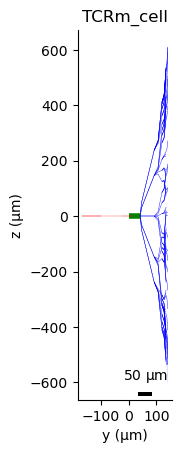

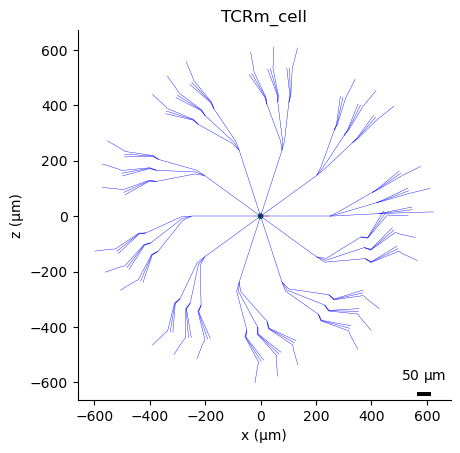

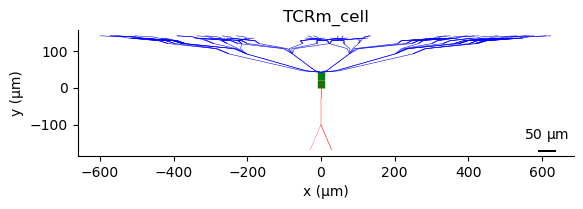

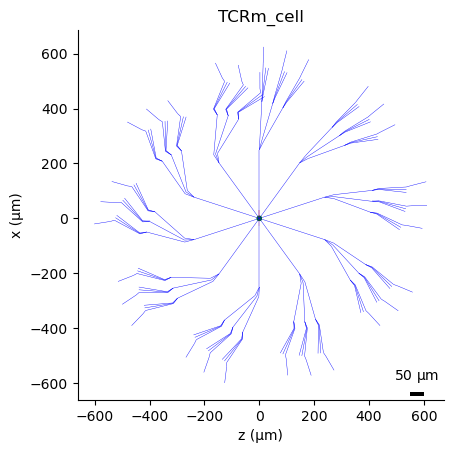

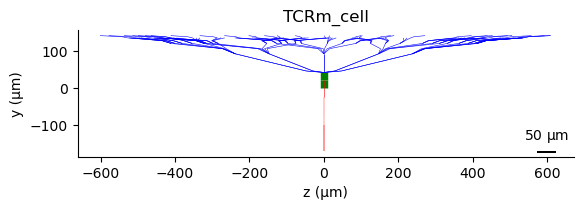

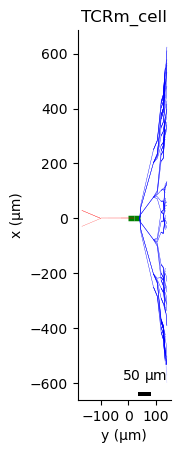

In [6]:
if __name__ == "__main__":
    main()